# Hướng dẫn Analysis Bot & Signal Visualization

Tutorial này bao gồm:

1. **Query dữ liệu** OHLCV cho SHB, VHM từ đầu năm 2026
2. **Sử dụng strategies** (RSI, MACD, SMA) với `attach_snapshot=True`
3. **Batch analysis** – quét tín hiệu trên toàn bộ DataFrame
4. **Backtest với AnalysisBot** – chạy bot qua engine
5. **Visualization** – plot biểu đồ nến + indicator + Entry/SL/TP
6. **SignalStore** – lưu & query signals đã accept

## 1. Query dữ liệu OHLCV

Sử dụng `query_ohlcv_grouped()` để lấy dữ liệu daily cho **SHB** và **VHM** từ Q4-2025 (cần lookback cho indicator) đến hiện tại.

In [1]:
import pandas as pd
from vnstock_forecast.engine.data.query import query_ohlcv_grouped

# Lấy dữ liệu từ 2025-10-01 để có đủ lookback cho MACD (slow=26 + signal=9)
from_ts = int(pd.Timestamp("2025-01-01").timestamp())
grouped = query_ohlcv_grouped(
    symbols=["SHB", "VHM"],
    resolutions="D",
    from_ts=from_ts,
)

# Truy cập: grouped[resolution][symbol] → DataFrame OHLCV
df_shb = grouped["D"]["SHB"]
df_vhm = grouped["D"]["VHM"]

print(f"SHB: {df_shb.shape[0]} bars,  {df_shb.index[0]}  →  {df_shb.index[-1]}")
print(f"VHM: {df_vhm.shape[0]} bars,  {df_vhm.index[0]}  →  {df_vhm.index[-1]}")
df_shb.tail(3)

SHB: 291 bars,  1735776000  →  1773360000
VHM: 291 bars,  1735776000  →  1773360000


,Open,High,Low,Close,Volume
Timestamp,,,,,
1773014400,14550.0,14900.0,14350.0,14350.0,123268700.0
1773187200,14550.0,14550.0,14400.0,14500.0,10699500.0
1773360000,14650.0,14950.0,14600.0,14950.0,57514000.0


## 2. Batch Analysis – quét tín hiệu với từng Strategy

Mỗi strategy (RSICrossover, MACDCrossover, SMACrossover) có thể chạy độc lập qua `analyze_batch()`.

Bật `attach_snapshot = True` để mỗi signal mang theo đủ dữ liệu OHLCV + indicator overlays dùng cho visualization.

In [3]:
from vnstock_forecast.forecast.registry import get_technique, list_technique_names
print("Available techniques:")
for name in list_technique_names():
    print(f"  - {name}")
    print(f"    {get_technique(name)}")

Available techniques:
  - macd_crossover
    <class 'user.builtin.bots.technical.strategies.macd_crossover.MACDCrossover'>
  - rsi_crossover
    <class 'user.builtin.bots.technical.strategies.rsi_crossover.RSICrossover'>
  - sma_crossover
    <class 'user.builtin.bots.technical.strategies.sma_crossover.SMACrossover'>
  - sma_short_crossover
    <class 'user.builtin.bots.technical.strategies.sma_short_crossover.SMAShortCrossover'>


In [4]:
import sys
from pathlib import Path

# Bootstrap path để import được cả `src/` và thư mục `user/`
project_root = None
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "pyproject.toml").exists():
        project_root = parent
        break
if project_root is None:
    project_root = Path.cwd()

src_dir = project_root / "src"
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
if src_dir.exists() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from user.builtin.bots.technical.strategies import (
    MACDCrossover,
    RSICrossover,
    SMACrossover,
)
from vnstock_forecast.forecast.signal import SignalDirection

# ---- Khởi tạo strategies, bật snapshot ----
rsi = RSICrossover(period=14, oversold=30, overbought=70, sl_pct=0.07, tp_pct=0.10)
rsi.attach_snapshot = True

macd = MACDCrossover(fast_period=12, slow_period=26, signal_period=9)
macd.attach_snapshot = True

sma = SMACrossover(period=20, sl_pct=0.05, tp_pct=0.08)
sma.attach_snapshot = True

# ---- Quét tín hiệu trên SHB ----
rsi_signals = rsi.analyze_batch(df_shb, "SHB")
macd_signals = macd.analyze_batch(df_shb, "SHB")
sma_signals = sma.analyze_batch(df_shb, "SHB")

all_signals = rsi_signals + macd_signals + sma_signals
buys = [s for s in all_signals if s.direction == SignalDirection.BUY]
sells = [s for s in all_signals if s.direction == SignalDirection.SELL]

print(f"RSI  → {len(rsi_signals)} signals")
print(f"MACD → {len(macd_signals)} signals")
print(f"SMA  → {len(sma_signals)} signals")
print(f"\nTổng: {len(all_signals)} signals ({len(buys)} BUY, {len(sells)} SELL)")

# Xem nhanh
for s in all_signals:
    direction = "🟢 BUY " if s.is_buy else "🔴 SELL"
    snap_ok = "✓ snap" if s.snapshot else "✗"
    entry_info = f"entry={s.trade_plan.entry:,.0f}" if s.trade_plan else ""
    print(f"  {direction} [{s.technique:16s}] {s.timestamp.date()} {entry_info:>14s}  conf={s.confidence:.2f}  {snap_ok}")

/mnt/data/QuickAccess/Documents/4.Tin/Projects/vnstock-forecast/user/builtin/bots/technical/strategies/rsi_crossover.py:161: UserWarning: Discarding nonzero nanoseconds in conversion.
  timestamp = pd.Timestamp(df.index[i]).to_pydatetime()
/mnt/data/QuickAccess/Documents/4.Tin/Projects/vnstock-forecast/user/builtin/bots/technical/strategies/rsi_crossover.py:161: UserWarning: Discarding nonzero nanoseconds in conversion.
  timestamp = pd.Timestamp(df.index[i]).to_pydatetime()
/mnt/data/QuickAccess/Documents/4.Tin/Projects/vnstock-forecast/user/builtin/bots/technical/strategies/rsi_crossover.py:161: UserWarning: Discarding nonzero nanoseconds in conversion.
  timestamp = pd.Timestamp(df.index[i]).to_pydatetime()
/mnt/data/QuickAccess/Documents/4.Tin/Projects/vnstock-forecast/user/builtin/bots/technical/strategies/rsi_crossover.py:161: UserWarning: Discarding nonzero nanoseconds in conversion.
  timestamp = pd.Timestamp(df.index[i]).to_pydatetime()
/mnt/data/QuickAccess/Documents/4.Tin/Pr

RSI  → 9 signals
MACD → 22 signals
SMA  → 29 signals

Tổng: 60 signals (26 BUY, 34 SELL)
  🔴 SELL [rsi_crossover   ] 1970-01-01                 conf=0.60  ✓ snap
  🔴 SELL [rsi_crossover   ] 1970-01-01                 conf=0.60  ✓ snap
  🔴 SELL [rsi_crossover   ] 1970-01-01                 conf=0.60  ✓ snap
  🔴 SELL [rsi_crossover   ] 1970-01-01                 conf=0.60  ✓ snap
  🔴 SELL [rsi_crossover   ] 1970-01-01                 conf=0.60  ✓ snap
  🔴 SELL [rsi_crossover   ] 1970-01-01                 conf=0.60  ✓ snap
  🔴 SELL [rsi_crossover   ] 1970-01-01                 conf=0.60  ✓ snap
  🔴 SELL [rsi_crossover   ] 1970-01-01                 conf=0.60  ✓ snap
  🟢 BUY  [rsi_crossover   ] 1970-01-01   entry=14,500  conf=0.60  ✓ snap
  🟢 BUY  [macd_crossover  ] 1970-01-01    entry=7,915  conf=0.55  ✓ snap
  🔴 SELL [macd_crossover  ] 1970-01-01                 conf=0.55  ✓ snap
  🟢 BUY  [macd_crossover  ] 1970-01-01    entry=7,877  conf=0.55  ✓ snap
  🔴 SELL [macd_crossover  ] 1970-01

## 3. Visualization – Plot Signal trên biểu đồ nến

`plot_signal()` nhận trực tiếp `Signal` (có snapshot) hoặc `SignalSnapshot`, render biểu đồ nến gồm:
- **Entry** (xanh dương), **SL** (đỏ), **TP** (xanh lá) tại đúng mức giá
- Vùng tô risk (đỏ nhạt) / reward (xanh nhạt)
- Indicator subplot (RSI, MACD, …)
- Mũi tên đánh dấu thời điểm phát signal

In [7]:
%matplotlib inline
from vnstock_forecast.forecast.visualization import plot_signal

# ---- Plot signal BUY đầu tiên (RSI) ----
rsi_buys = [s for s in rsi_signals if s.is_buy and s.snapshot]
if rsi_buys:
    sig = rsi_buys[0]
    print(sig.snapshot)
    print(f"RSI BUY @ {sig.timestamp.date()} — {sig.reason}")
    print(f"  Entry: {sig.trade_plan.entry:,.0f}  SL: {sig.trade_plan.stop_loss:,.0f}  TP: {sig.trade_plan.take_profit:,.0f}")
    print(f"  R:R = 1:{sig.trade_plan.rr_ratio():.2f}")
    plot_signal(sig, extend_bars=20, show=True, figsize=(16, 9))
else:
    print("Không có RSI BUY signal nào cho SHB trong khoảng dữ liệu này.")

SignalSnapshot(ohlcv=Empty DataFrame
Columns: [Open, High, Low, Close, Volume]
Index: [], entry=14500.0, stop_loss=13485.0, take_profit=15950.0, signal_time=datetime.datetime(1970, 1, 1, 0, 0, 1, 773187), time_limit=None, resolution='D', symbol='SHB', hlines=[HLine(value=30, color='#4CAF50', linestyle='--', linewidth=0.8, label='Oversold (30)', panel=2), HLine(value=70, color='#F44336', linestyle='--', linewidth=0.8, label='Overbought (70)', panel=2)], vlines=[], rectangles=[], trendlines=[], indicators=[IndicatorLine(name='RSI(14)', data=Series([], Name: Close, dtype: float64), color='#7B1FA2', linestyle='-', linewidth=1.2, panel=2, ylabel='RSI', secondary_y=False, type='line', alpha=1.0)])
RSI BUY @ 1970-01-01 — RSI(14) vượt lên 30
  Entry: 14,500  SL: 13,485  TP: 15,950
  R:R = 1:1.43


IndexError: index -1 is out of bounds for axis 0 with size 0

In [ ]:
# ---- Plot MACD BUY signal trên SHB ----
macd_buys = [s for s in macd_signals if s.is_buy and s.snapshot]
if macd_buys:
    sig = macd_buys[0]
    print(f"MACD BUY @ {sig.timestamp.date()} — {sig.reason}")
    plot_signal(sig, extend_to_limit=False, show=True, figsize=(16, 9))
else:
    print("Không có MACD BUY signal nào.")

In [ ]:
# ---- Plot SMA BUY signal trên SHB ----
sma_buys = [s for s in sma_signals if s.is_buy and s.snapshot]
if sma_buys:
    sig = sma_buys[0]
    print(f"SMA BUY @ {sig.timestamp.date()} — {sig.reason}")
    plot_signal(sig, extend_to_limit=False, show=True, figsize=(16, 9))
else:
    print("Không có SMA BUY signal nào.")

## 4. Backtest với AnalysisBot

`AnalysisBot` tổ hợp nhiều technique, chạy qua `BacktestEngine` bar-by-bar.  
Bật `attach_snapshot = True` trên mỗi technique để signals trong `bot.signal_history` đều có snapshot sẵn sàng plot.

In [8]:
from user.builtin.bots.technical.bot import AnalysisBot
from vnstock_forecast.engine.backtest.engine import BacktestEngine
from user.builtin.bots.technical.strategies import RSICrossover, MACDCrossover, SMACrossover

# ---- Tạo bot kết hợp RSI + MACD ----
rsi_tech = RSICrossover(period=14)
rsi_tech.attach_snapshot = True

macd_tech = MACDCrossover()
macd_tech.attach_snapshot = True

sma_tech = SMACrossover()
sma_tech.attach_snapshot = True

bot = AnalysisBot(
    name="sma_tech",
    techniques=[macd_tech],
    allocation=0.3,         # 30% vốn mỗi lệnh mua
)

# ---- Chạy backtest – dùng cả SHB + VHM ----
data = grouped["D"]  # {"SHB": df, "VHM": df}

engine = BacktestEngine(
    initial_cash=100000000,  # 500 triệu VND
    commission_rate=0.0015,
    settlement_days=2,
)

report = engine.run(bot, data, start="2025-06-01")
report.print_summary()

  BACKTEST REPORT: sma_tech
  Symbols:        SHB, VHM
  Period:         2025-06-02 → 2026-03-13
  Commission:     0.15%
------------------------------------------------------------
  Initial Cash:       100,000,000
  Final Equity:       104,252,949
  Total PnL:            4,837,282
  Total Return:             4.25%
------------------------------------------------------------
  Trades:                      12
  Wins:                         7
  Losses:                       5
  Win Rate:                 58.3%
  Avg Win:                  7.26%
  Avg Loss:                -3.90%
  R:R Ratio:                 1.86
  Max Drawdown:             2.06%
------------------------------------------------------------
  Close Reasons:  {'manual': 6, 'take_profit': 5, 'stop_loss': 1}


In [9]:
report.trade_history()

,id,symbol,entry_time,exit_time,entry_price,exit_price,quantity,stop_loss,take_profit,pnl,pnl_pct,close_reason
0,08886258,VHM,2025-06-25,2025-07-03,77900.0000,76300.0,211,72447.0,85690.0,-337600.0,-2.05,manual
1,644e7af5,VHM,2025-07-08,2025-07-11,79200.0000,87120.0,173,73656.0,87120.0,1370160.0,10.00,take_profit
2,f3f62e2f,SHB,2025-07-07,2025-07-24,12299.9988,13530.0,1336,11439.0,13530.0,1643282.0,10.00,take_profit
3,fef70a80,VHM,2025-08-21,2025-09-05,99800.0000,100000.0,169,92814.0,109780.0,33800.0,0.20,manual
4,fc48e695,VHM,2025-10-08,2025-10-10,107500.0000,118250.0,157,99975.0,118250.0,1687750.0,10.00,take_profit
5,02414a00,SHB,2025-10-09,2025-10-20,17900.0000,16850.0,789,16647.0,19690.0,-828450.0,-5.87,manual
6,7ce9c888,VHM,2025-11-19,2025-12-01,96900.0000,106590.0,146,90117.0,106590.0,1414740.0,10.00,take_profit
7,57092a53,SHB,2025-11-13,2025-12-10,16350.0000,16450.0,1042,15205.5,17985.0,104200.0,0.61,manual
8,557b31d7,VHM,2025-12-22,2025-12-24,107400.0000,118140.0,160,99882.0,118140.0,1718400.0,10.00,take_profit
9,a9d1df71,SHB,2025-12-24,2026-01-21,16900.0000,16450.0,1038,15717.0,18590.0,-467100.0,-2.66,manual


In [10]:
# ---- Xem signal_history từ backtest ----
print(f"Bot đã ghi nhận {len(bot.signal_history)} signals trong quá trình backtest:\n")

for s in bot.signal_history:
    d = "🟢 BUY " if s.is_buy else "🔴 SELL"
    snap = "✓ snap" if s.snapshot else ""
    entry = f"entry={s.trade_plan.entry:,.0f}" if s.trade_plan else ""
    print(f"  {d} {s.symbol:4s} [{s.technique:16s}] {s.timestamp.date()}  {entry:>14s}  {snap}")

Bot đã ghi nhận 18 signals trong quá trình backtest:

  🟢 BUY  VHM  [macd_crossover  ] 2025-06-25    entry=77,900  ✓ snap
  🔴 SELL VHM  [macd_crossover  ] 2025-07-03                  ✓ snap
  🟢 BUY  SHB  [macd_crossover  ] 2025-07-07    entry=12,300  ✓ snap
  🟢 BUY  VHM  [macd_crossover  ] 2025-07-08    entry=79,200  ✓ snap
  🟢 BUY  VHM  [macd_crossover  ] 2025-08-21    entry=99,800  ✓ snap
  🔴 SELL VHM  [macd_crossover  ] 2025-09-05                  ✓ snap
  🟢 BUY  VHM  [macd_crossover  ] 2025-10-08   entry=107,500  ✓ snap
  🟢 BUY  SHB  [macd_crossover  ] 2025-10-09    entry=17,900  ✓ snap
  🔴 SELL SHB  [macd_crossover  ] 2025-10-20                  ✓ snap
  🟢 BUY  SHB  [macd_crossover  ] 2025-11-13    entry=16,350  ✓ snap
  🟢 BUY  VHM  [macd_crossover  ] 2025-11-19    entry=96,900  ✓ snap
  🔴 SELL SHB  [macd_crossover  ] 2025-12-10                  ✓ snap
  🟢 BUY  VHM  [macd_crossover  ] 2025-12-22   entry=107,400  ✓ snap
  🟢 BUY  SHB  [macd_crossover  ] 2025-12-24    entry=16,900  ✓

[Backtest] macd_crossover BUY SHB @ 2025-07-07
  Entry: 12,300  SL: 11,439  TP: 13,530


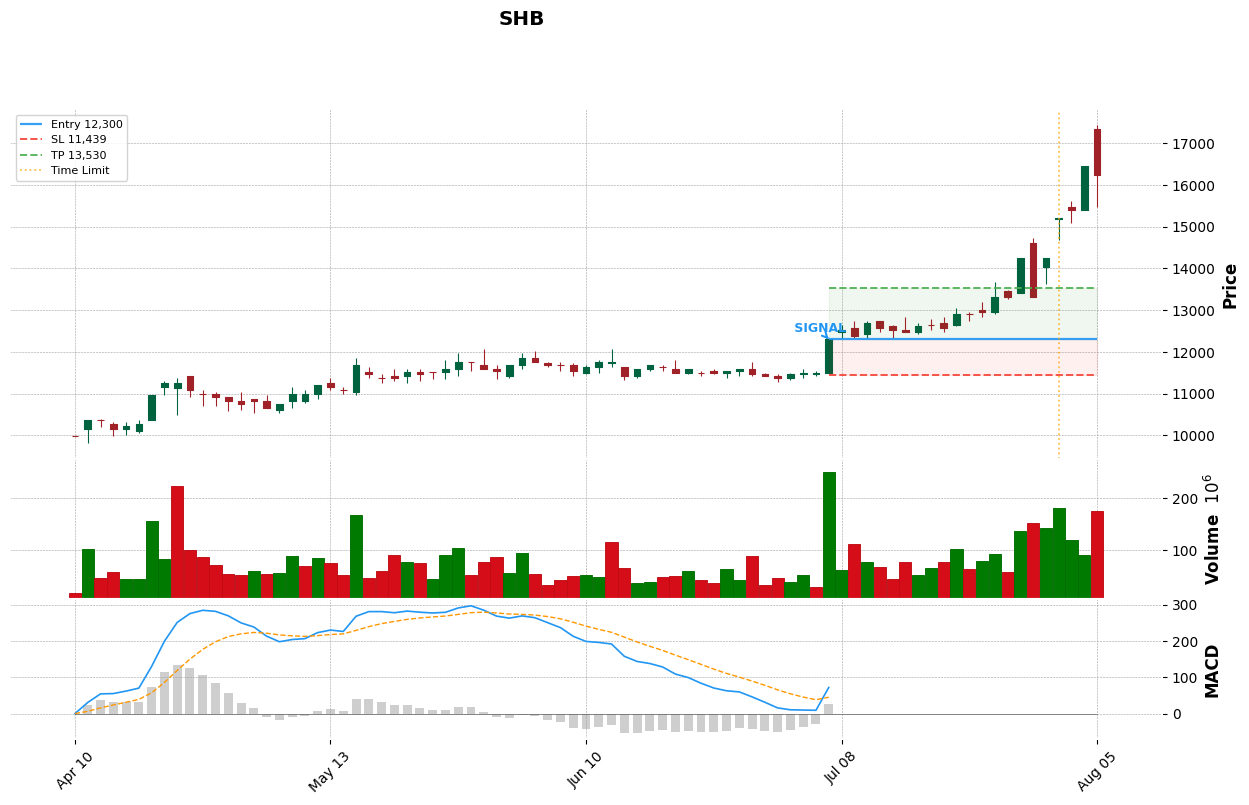

In [11]:
# ---- Plot BUY signal đầu tiên từ backtest history ----
from vnstock_forecast.forecast.visualization import plot_signal
bt_buys = [s for s in bot.signal_history if s.is_buy and s.snapshot]
if bt_buys:
    sig = bt_buys[1]
    print(f"[Backtest] {sig.technique} BUY {sig.symbol} @ {sig.timestamp.date()}")
    print(f"  Entry: {sig.trade_plan.entry:,.0f}  SL: {sig.trade_plan.stop_loss:,.0f}  TP: {sig.trade_plan.take_profit:,.0f}")
    plot_signal(sig, extend_bars=30, figsize=(16, 9))
else:
    print("Không có BUY signal với snapshot trong backtest.")

## 5. Equity Curve & Trade History

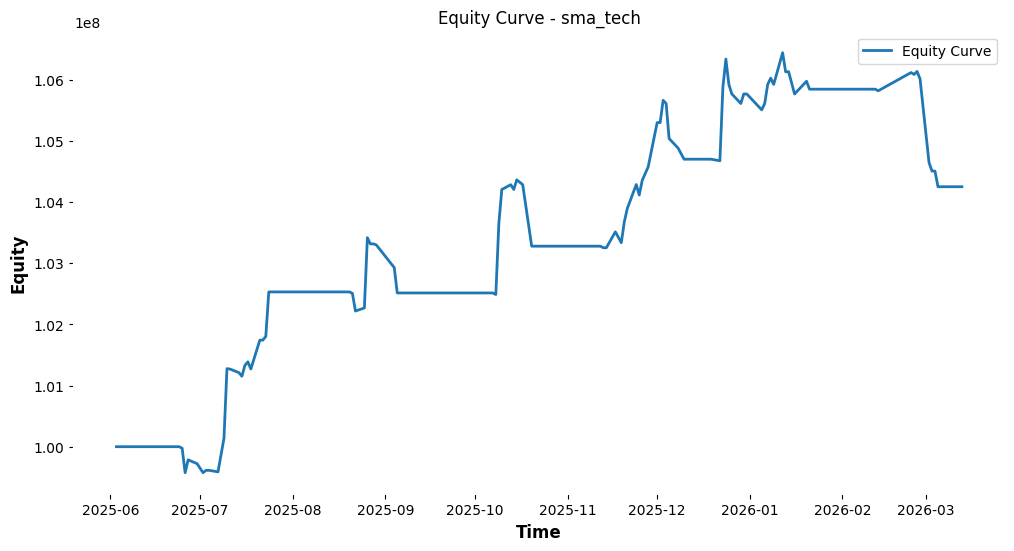

,id,symbol,entry_time,exit_time,entry_price,exit_price,quantity,stop_loss,take_profit,pnl,pnl_pct,close_reason
0,08886258,VHM,2025-06-25,2025-07-03,77900.0000,76300.0,211,72447.0,85690.0,-337600.0,-2.05,manual
1,644e7af5,VHM,2025-07-08,2025-07-11,79200.0000,87120.0,173,73656.0,87120.0,1370160.0,10.00,take_profit
2,f3f62e2f,SHB,2025-07-07,2025-07-24,12299.9988,13530.0,1336,11439.0,13530.0,1643282.0,10.00,take_profit
3,fef70a80,VHM,2025-08-21,2025-09-05,99800.0000,100000.0,169,92814.0,109780.0,33800.0,0.20,manual
4,fc48e695,VHM,2025-10-08,2025-10-10,107500.0000,118250.0,157,99975.0,118250.0,1687750.0,10.00,take_profit
5,02414a00,SHB,2025-10-09,2025-10-20,17900.0000,16850.0,789,16647.0,19690.0,-828450.0,-5.87,manual
6,7ce9c888,VHM,2025-11-19,2025-12-01,96900.0000,106590.0,146,90117.0,106590.0,1414740.0,10.00,take_profit
7,57092a53,SHB,2025-11-13,2025-12-10,16350.0000,16450.0,1042,15205.5,17985.0,104200.0,0.61,manual
8,557b31d7,VHM,2025-12-22,2025-12-24,107400.0000,118140.0,160,99882.0,118140.0,1718400.0,10.00,take_profit
9,a9d1df71,SHB,2025-12-24,2026-01-21,16900.0000,16450.0,1038,15717.0,18590.0,-467100.0,-2.66,manual


In [12]:
# Equity curve
report.plot_equity()

# Trade history table
report.trade_history()

## 6. SignalStore – Lưu & Query Signals

`SignalStore` lưu mỗi signal ra file pickle, query theo technique / symbol / direction / time range.

In [13]:
import tempfile
from vnstock_forecast.forecast.visualization import SignalStore

# Tạo store tạm (thực tế dùng đường dẫn cố định, ví dụ "outputs/signals")
store_dir = tempfile.mkdtemp(prefix="signal_store_")
store = SignalStore(store_dir)

# Lưu tất cả signals từ backtest
ids = store.save_many(bot.signal_history)
print(f"Đã lưu {len(ids)} signals vào {store_dir}")
for sid in ids:
    print(f"  • {sid}")

# ---- Query ----
# Tìm tất cả BUY signals cho SHB
shb_buys = store.query(symbol="SHB", direction=SignalDirection.BUY)
print(f"\nQuery SHB BUY → {len(shb_buys)} kết quả")

# Tìm signals theo technique
macd_sigs = store.query(technique="macd_crossover")
print(f"Query macd_crossover → {len(macd_sigs)} kết quả")

Đã lưu 18 signals vào /tmp/signal_store_iycl0n2f
  • macd_crossover__VHM__20250625_000000__23bf8b2f
  • macd_crossover__VHM__20250703_000000__8e11e044
  • macd_crossover__SHB__20250707_000000__afa62eb9
  • macd_crossover__VHM__20250708_000000__99c5ece2
  • macd_crossover__VHM__20250821_000000__4b9a4c48
  • macd_crossover__VHM__20250905_000000__c0ad8a0f
  • macd_crossover__VHM__20251008_000000__80ba4b99
  • macd_crossover__SHB__20251009_000000__b65dde98
  • macd_crossover__SHB__20251020_000000__f417eb25
  • macd_crossover__SHB__20251113_000000__465cd014
  • macd_crossover__VHM__20251119_000000__0f4f7fc5
  • macd_crossover__SHB__20251210_000000__a90b57b8
  • macd_crossover__VHM__20251222_000000__ae952d4a
  • macd_crossover__SHB__20251224_000000__5d19c4b2
  • macd_crossover__SHB__20260121_000000__640e056b
  • macd_crossover__VHM__20260213_000000__cdda2c29
  • macd_crossover__SHB__20260224_000000__95e25e43
  • macd_crossover__SHB__20260305_000000__66d7f74a

Query SHB BUY → 5 kết quả
Query 

Loaded: macd_crossover SHB @ 2025-07-07


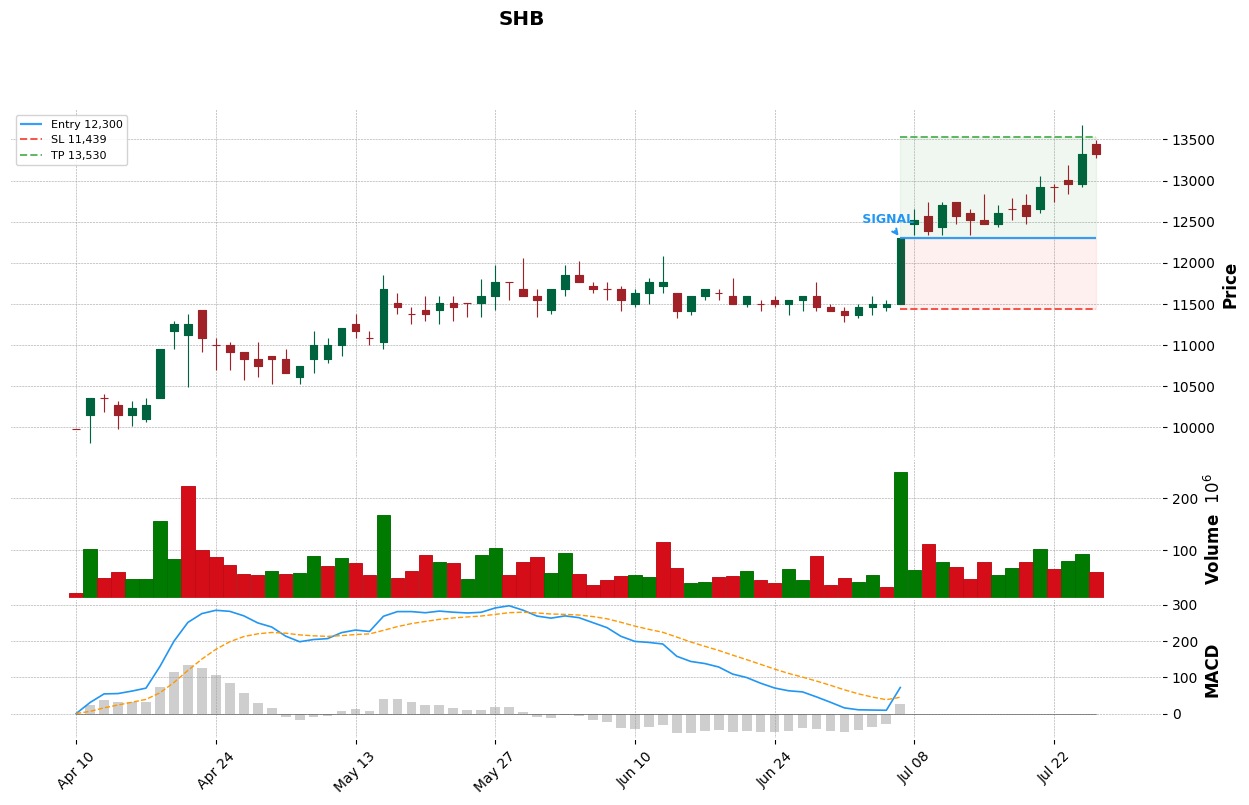

In [15]:
# ---- Load & plot từ store ----
if shb_buys:
    loaded = shb_buys[0]
    print(f"Loaded: {loaded.technique} {loaded.symbol} @ {loaded.timestamp.date()}")
    if loaded.snapshot:
        plot_signal(loaded, extend_bars=20, figsize=(16, 9))
    else:
        print("Signal không có snapshot.")